In [1]:
s="hello"
print(s)

hello


In [4]:
def IDfunc(a:int)->int:
    return a

IDfunc(2)

2

In [1]:
!uv add ipykernel

error: No `pyproject.toml` found in current directory or any parent directory


Sampling: dt ≈ 14.7 ns (67.9 MHz)
Min distance: 67 pts (1.0 µs)
Data range: Current -0.015456 - 0.574022 A

Detected spikes: 15
Threshold: 0.150 A
Min distance: 1.0 µs

Spike peak statistics:
  Min peak: 0.499488 A
  Max peak: 0.511811 A
  Mean peak: 0.504935 A
  Std peak: 0.004899 A

ISI Statistics:
  Mean ISI: 0.013007 ms (13.007 µs)
  Std ISI:  0.001763 ms
  CV:       0.1355
  Freq:     76883.45 kHz
  Range:    0.010107 - 0.014458 ms


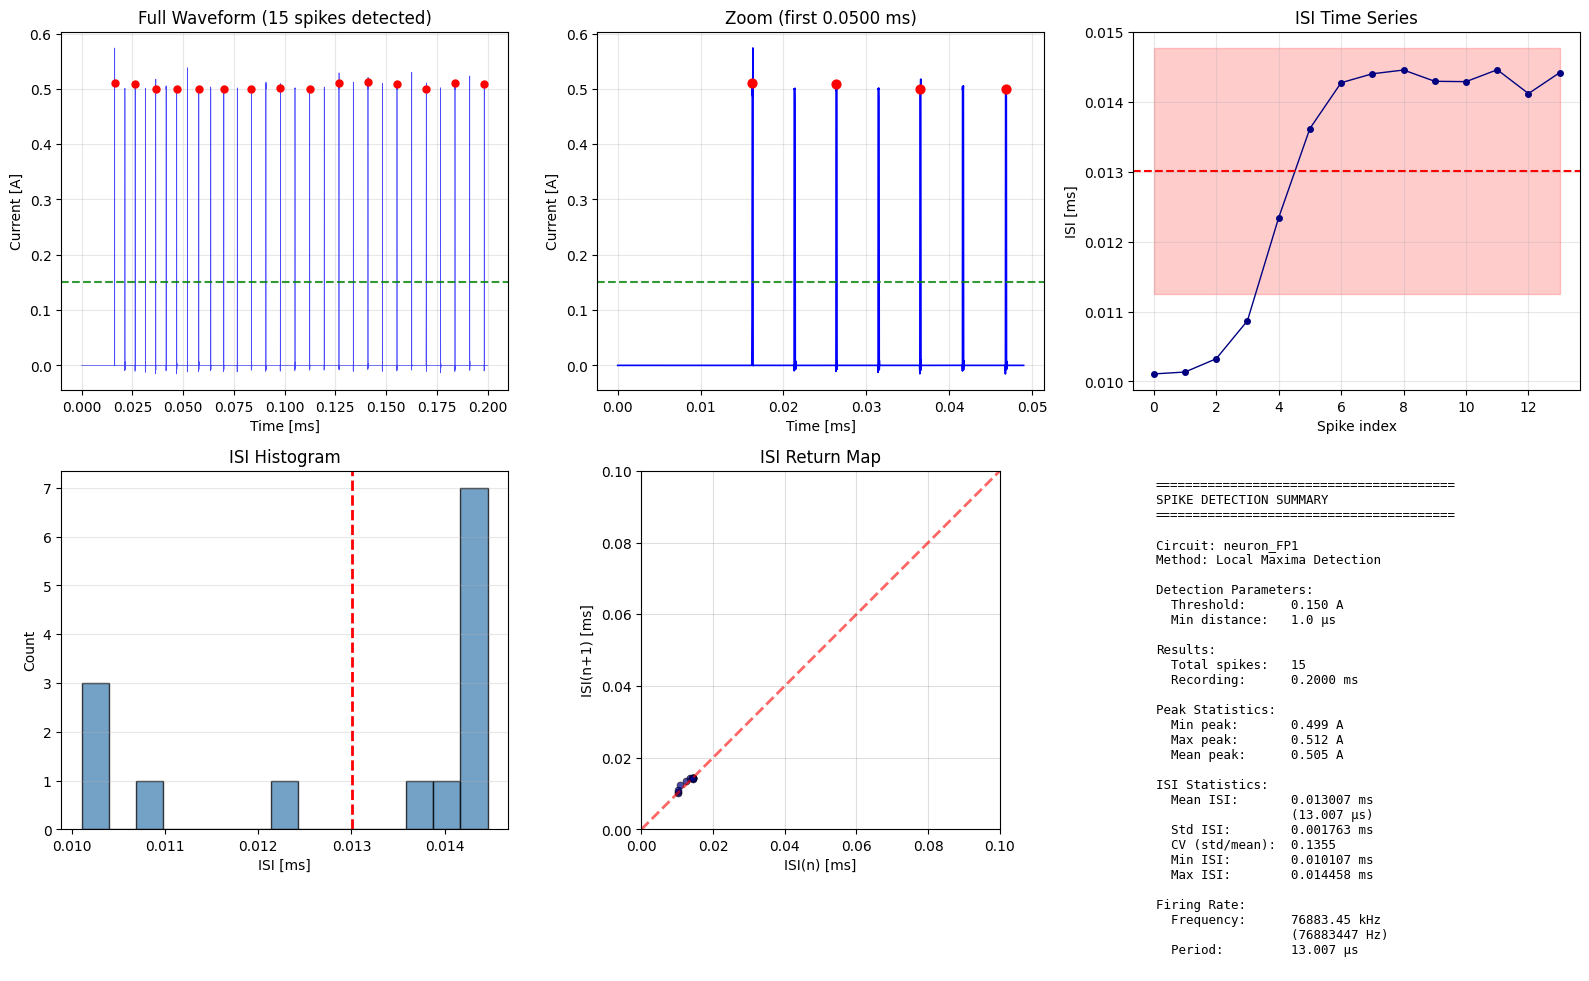


First 10 ISI values [ms]:
  ISI[ 0] = 0.010107 ms (10.107 µs)
  ISI[ 1] = 0.010134 ms (10.134 µs)
  ISI[ 2] = 0.010324 ms (10.324 µs)
  ISI[ 3] = 0.010868 ms (10.868 µs)
  ISI[ 4] = 0.012341 ms (12.341 µs)
  ISI[ 5] = 0.013617 ms (13.617 µs)
  ISI[ 6] = 0.014273 ms (14.273 µs)
  ISI[ 7] = 0.014401 ms (14.401 µs)
  ISI[ 8] = 0.014454 ms (14.454 µs)
  ISI[ 9] = 0.014293 ms (14.293 µs)



In [3]:
# ================ ISI Return Map - Peak detection using derivative ================
import csv, numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ---- Settings ----
CSV_PATH = Path('./waveforms_v_ap.csv')

MIN_HEIGHT = 0.15     # しきい値 [A]
MIN_DISTANCE_US = 1.0 # 最小スパイク間隔 [µs]

TIME_COL, CURR_COL = 0, 1

# ---- Load CSV ----
t, i_data = [], []
with CSV_PATH.open(errors='ignore') as f:
    r = csv.reader(f)
    for row in r:
        if len(row) < 2: 
            continue
        try:
            t.append(float(row[TIME_COL].strip()))
            i_data.append(float(row[CURR_COL].strip()))
        except ValueError:
            continue

t = np.asarray(t)
i_data = np.asarray(i_data)
assert t.size > 1 and t.size == i_data.size, "CSVの2列データを確認してください。"

dt = float(np.median(np.diff(t)))
min_distance_pts = max(1, int((MIN_DISTANCE_US * 1e-6) / dt))

print(f"Sampling: dt ≈ {dt*1e9:.1f} ns ({1/dt/1e6:.1f} MHz)")
print(f"Min distance: {min_distance_pts} pts ({MIN_DISTANCE_US} µs)")
print(f"Data range: Current {i_data.min():.6f} - {i_data.max():.6f} A")

# ---- Peak detection using derivative ----
spk_idx = []

for i in range(1, len(i_data) - 1):
    # しきい値を超えている
    if i_data[i] > MIN_HEIGHT:
        # 極大値判定：前より大きく、後より大きい
        if i_data[i-1] < i_data[i] and i_data[i] > i_data[i+1]:
            # 最小距離チェック
            if len(spk_idx) == 0 or (i - spk_idx[-1]) >= min_distance_pts:
                spk_idx.append(i)

spk_idx = np.asarray(spk_idx, dtype=int)
spike_t = t[spk_idx] * 1e3  # ms単位
spike_i = i_data[spk_idx]

print(f"\n{'='*60}")
print(f"Detected spikes: {len(spike_t)}")
print(f"Threshold: {MIN_HEIGHT:.3f} A")
print(f"Min distance: {MIN_DISTANCE_US} µs")
print(f"{'='*60}\n")

# スパイクピーク値の統計
if len(spike_i) > 0:
    print(f"Spike peak statistics:")
    print(f"  Min peak: {spike_i.min():.6f} A")
    print(f"  Max peak: {spike_i.max():.6f} A")
    print(f"  Mean peak: {spike_i.mean():.6f} A")
    print(f"  Std peak: {spike_i.std():.6f} A")
    print()

# ---- ISI analysis & plots ----
if len(spike_t) >= 3:
    isi = np.diff(spike_t)
    
    # 統計情報
    mean_isi = isi.mean()
    std_isi = isi.std()
    cv = std_isi / mean_isi if mean_isi > 0 else 0
    freq_khz = 1000 / mean_isi if mean_isi > 0 else 0
    
    print(f"ISI Statistics:")
    print(f"  Mean ISI: {mean_isi:.6f} ms ({mean_isi*1000:.3f} µs)")
    print(f"  Std ISI:  {std_isi:.6f} ms")
    print(f"  CV:       {cv:.4f}")
    print(f"  Freq:     {freq_khz:.2f} kHz")
    print(f"  Range:    {isi.min():.6f} - {isi.max():.6f} ms")
    
    # ---- Plotting ----
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    
    # 1. Full waveform
    ax1 = axes[0, 0]
    ax1.plot(t*1e3, i_data, 'b-', lw=0.5, alpha=0.7)
    ax1.scatter(spike_t, spike_i, c='r', s=25, zorder=5)
    ax1.axhline(MIN_HEIGHT, color='green', ls='--', lw=1.5, alpha=0.8)
    ax1.set(xlabel='Time [ms]', ylabel='Current [A]', 
            title=f'Full Waveform ({len(spike_t)} spikes detected)')
    ax1.grid(alpha=0.3)
    
    # 2. Zoom view
    ax2 = axes[0, 1]
    t_zoom = min(0.05, (t.max()-t.min())*1e3/4)
    msk = (t*1e3) <= t_zoom
    ax2.plot(t[msk]*1e3, i_data[msk], 'b-', lw=1.2)
    zsp = spike_t <= t_zoom
    if np.any(zsp):
        ax2.scatter(spike_t[zsp], spike_i[zsp], c='r', s=40, zorder=5)
    ax2.axhline(MIN_HEIGHT, color='green', ls='--', lw=1.5, alpha=0.8)
    ax2.set(xlabel='Time [ms]', ylabel='Current [A]', 
            title=f'Zoom (first {t_zoom:.4f} ms)')
    ax2.grid(alpha=0.3)
    
    # 3. ISI time series
    ax3 = axes[0, 2]
    ax3.plot(np.arange(len(isi)), isi, 'o-', ms=4, lw=1, color='navy')
    ax3.axhline(mean_isi, color='r', ls='--', lw=1.5)
    ax3.fill_between(np.arange(len(isi)), mean_isi-std_isi, mean_isi+std_isi, 
                      alpha=0.2, color='red')
    ax3.set(xlabel='Spike index', ylabel='ISI [ms]', title='ISI Time Series')
    ax3.grid(alpha=0.3)
    
    # 4. ISI histogram
    ax4 = axes[1, 0]
    n_bins = max(15, min(50, int(np.sqrt(len(isi))*2)))
    ax4.hist(isi, bins=n_bins, edgecolor='k', alpha=0.75, color='steelblue')
    ax4.axvline(mean_isi, color='r', ls='--', lw=2)
    ax4.set(xlabel='ISI [ms]', ylabel='Count', title='ISI Histogram')
    ax4.grid(alpha=0.3, axis='y')
    
    # 5. Return map (固定範囲 0.0-0.8 ms)
    ax5 = axes[1, 1]
    ax5.scatter(isi[:-1], isi[1:], s=25, alpha=0.7, c='navy', edgecolors='k', linewidth=0.5)
    ax5.plot([0.0, 0.8], [0.0, 0.8], 'r--', lw=2, alpha=0.6)
    ax5.set(xlabel='ISI(n) [ms]', ylabel='ISI(n+1) [ms]', 
            title='ISI Return Map',
            xlim=(0.0, 0.1), ylim=(0.0, 0.1),
            aspect='equal')
    ax5.grid(alpha=0.4)
    
    # 6. Statistics panel
    ax6 = axes[1, 2]
    stats_text = (
        f"{'='*40}\n"
        f"SPIKE DETECTION SUMMARY\n"
        f"{'='*40}\n\n"
        f"Circuit: neuron_FP1\n"
        f"Method: Local Maxima Detection\n\n"
        f"Detection Parameters:\n"
        f"  Threshold:      {MIN_HEIGHT:.3f} A\n"
        f"  Min distance:   {MIN_DISTANCE_US:.1f} µs\n\n"
        f"Results:\n"
        f"  Total spikes:   {len(spike_t)}\n"
        f"  Recording:      {t[-1]*1e3:.4f} ms\n\n"
        f"Peak Statistics:\n"
        f"  Min peak:       {spike_i.min():.3f} A\n"
        f"  Max peak:       {spike_i.max():.3f} A\n"
        f"  Mean peak:      {spike_i.mean():.3f} A\n\n"
        f"ISI Statistics:\n"
        f"  Mean ISI:       {mean_isi:.6f} ms\n"
        f"                  ({mean_isi*1000:.3f} µs)\n"
        f"  Std ISI:        {std_isi:.6f} ms\n"
        f"  CV (std/mean):  {cv:.4f}\n"
        f"  Min ISI:        {isi.min():.6f} ms\n"
        f"  Max ISI:        {isi.max():.6f} ms\n\n"
        f"Firing Rate:\n"
        f"  Frequency:      {freq_khz:.2f} kHz\n"
        f"                  ({freq_khz*1000:.0f} Hz)\n"
        f"  Period:         {mean_isi*1000:.3f} µs\n"
    )
    ax6.text(0.05, 0.98, stats_text, va='top', ha='left',
             family='monospace', fontsize=9, transform=ax6.transAxes)
    ax6.axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # コンソール出力: ISI詳細
    print(f"\n{'='*60}")
    print(f"First 10 ISI values [ms]:")
    for i, val in enumerate(isi[:min(10, len(isi))]):
        print(f"  ISI[{i:2d}] = {val:.6f} ms ({val*1000:.3f} µs)")
    print(f"{'='*60}\n")
    
else:
    print(f"\n警告: 検出スパイクが少なすぎます（{len(spike_t)} 本）")

# u-nullcline検証

TSN回路の`alpha = 0.05`におけるu-nullclineの存在を数値的に検証します。

**u-nullcline条件**: `dvU/dt = 0` → `g4(vU, alpha) = y * g5(VD)`

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def safe_exp(x):
    return np.exp(np.clip(x, -700, 700))

def g4(v, va):
    """g4関数 - ベクトル対応版"""
    v_arr = np.atleast_1d(v)
    result = np.zeros_like(v_arr, dtype=float)
    
    if va < 0.05:
        result[:] = 1.15e-12 * safe_exp(27 * va)
    else:
        threshold = 0.0816 * np.exp(5.5687 * va)
        mask = v_arr > threshold
        result[mask] = 1.27e-12 * safe_exp(28.5 * va)
        result[~mask] = 1e-12 * safe_exp((73.857 * va + 15.505) * v_arr[~mask])
    
    return result if not np.isscalar(v) else result[0]

def g5(b):
    """g5関数"""
    if b < 0.15:
        return 1.77e-6 * safe_exp(-11 * b)
    else:
        return 1.57e-5 * safe_exp(-28 * b)

# パラメータ設定
alpha = 0.05  # TSN_plot_fast.pyのalphaパラメータ
VD = 0.32
VDD = 0.6

print("=" * 70)
print("TSN回路のu-nullcline検証")
print("=" * 70)
print(f"\nパラメータ: alpha={alpha}, VD={VD}V, VDD={VDD}V\n")

# vU範囲でg4を計算
vU_range = np.linspace(0, VDD, 500)
g4_values = g4(vU_range, alpha)

# 閾値
threshold = 0.0816 * np.exp(5.5687 * alpha)
print(f"g4の閾値: {threshold:.6f}V")
print(f"g4の最大値: {g4_values.max():.6e} A (vU={vU_range[g4_values.argmax()]:.3f}V)")
print()

# y=0の場合
print("【Case 1: y=0 (通常時)】")
target_y0 = 0 * g5(VD)
print(f"  目標値: g4(vU, alpha) = y*g5(VD) = {target_y0:.6e} A")
print(f"  結論: g4 > 0 なので、u-nullcline は存在しない\n")

# y=VDDの場合
print("【Case 2: y=VDD (スパイク直後)】")
target_yVDD = VDD * g5(VD)
print(f"  目標値: g4(vU, alpha) = y*g5(VD) = {target_yVDD:.6e} A")
print(f"  g4の最大値: {g4_values.max():.6e} A")
print(f"  比率: y*g5 / g4_max = {target_yVDD / g4_values.max():.1f}倍")
print(f"  結論: g4の最大値 < y*g5 なので、u-nullcline は存在しない\n")

print("=" * 70)
print("【総合結論】")
print("=" * 70)
print("alpha = 0.05 では、u-nullclineは y=0, y=VDD の両方で存在しません。")
print("g4の値が y*g5 に到達できないためです。")
print("=" * 70)

In [ ]:
# グラフで可視化
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 左: 線形スケール
ax = axes[0]
ax.plot(vU_range, g4_values * 1e12, 'b-', linewidth=2.5, label='g4(vU, alpha=0.05)')
ax.axhline(target_y0 * 1e12, color='orange', linestyle='--', linewidth=2, label=f'y=0: target={target_y0:.2e} pA')
ax.axhline(target_yVDD * 1e12, color='red', linestyle='--', linewidth=2, label=f'y=VDD: target={target_yVDD*1e12:.1f} pA')
ax.axvline(threshold, color='green', linestyle=':', linewidth=1.5, alpha=0.7, label=f'閾値={threshold:.3f}V')
ax.set_xlabel('vU [V]', fontsize=13)
ax.set_ylabel('Current [pA]', fontsize=13)
ax.set_title('g4 vs y*g5 (線形スケール)', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, VDD)

# 右: 対数スケール
ax = axes[1]
ax.semilogy(vU_range, g4_values, 'b-', linewidth=2.5, label='g4(vU, alpha=0.05)')
ax.axhline(target_yVDD, color='red', linestyle='--', linewidth=2, label=f'y=VDD: target')
ax.axvline(threshold, color='green', linestyle=':', linewidth=1.5, alpha=0.7, label=f'閾値={threshold:.3f}V')
ax.fill_between(vU_range, g4_values.min(), g4_values.max(), alpha=0.2, color='blue', label='g4の範囲')
ax.set_xlabel('vU [V]', fontsize=13)
ax.set_ylabel('Current [A] (log)', fontsize=13)
ax.set_title('g4 vs y*g5 (対数スケール)', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, which='both')
ax.set_xlim(0, VDD)

plt.tight_layout()
plt.show()

print("\n✗ グラフからも明らか: g4の曲線と y*g5(赤線) は交差しない")

## 論文の式とMATLABコードの対応関係

### 論文の式(2)
$$C_u \frac{dv_U}{dt} = -g_4(v_U(t)) + g_5(V_D)$$

### MATLABの実装
```matlab
function k = fv(y,v,a,b,Cv)
    k = (-g4(v,a) + y*g5(b))/Cv;
end
```

### 重要な違い

**論文の式(2)には `y` が明示されていない！**

実際の一般式:
$$C_u \frac{dv_U}{dt} = -g_4(v_U) + \color{red}{y(t)} \cdot g_5(V_D)$$

where:
- $y(t) = 0$ (通常時)
- $y(t) = V_{DD}$ (スパイク直後)

論文の式(2)は **$y(t) = V_{DD}$ の特殊ケース**を示しています。

### g4関数の動作（VA < 0.05の場合）

論文の式(6)では線形近似:
$$g_4(v_U(t)) = (\alpha_4 V_A + \beta_4) v_U(t)$$

しかし、MATLABの実装（VA < 0.05）:
```matlab
if va<0.05
    current = 1.15*10^-12*exp(27*va);  % vに依存しない！
end
```

**→ VA < 0.05 では g4 は定数（vUに依存しない）**

In [1]:
# 論文とMATLABコードの対応を数値的に確認

import numpy as np

def safe_exp(x):
    return np.exp(np.clip(x, -700, 700))

def g4_matlab(v, va):
    """MATLABの実装"""
    if va < 0.05:
        return 1.15e-12 * safe_exp(27 * va)
    else:
        threshold = 0.0816 * np.exp(5.5687 * va)
        if v > threshold:
            return 1.27e-12 * safe_exp(28.5 * va)
        else:
            return 1e-12 * safe_exp((73.857 * va + 15.505) * v)

def g5_matlab(b):
    """MATLABの実装"""
    if b < 0.15:
        return 1.77e-6 * safe_exp(-11 * b)
    else:
        return 1.57e-5 * safe_exp(-28 * b)

print("=" * 80)
print("論文の式とMATLABコードの数値的対応確認")
print("=" * 80)
print()

# パラメータ（MATLABコードより）
VA = 0.0  # 'a' in MATLAB
VD = 0.32  # 'b' in MATLAB
VDD = 0.6

print("【パラメータ】")
print(f"  VA (a)  = {VA}")
print(f"  VD (b)  = {VD}V")
print(f"  VDD     = {VDD}V")
print()

print("【g4関数の検証】")
print("-" * 80)
print(f"VA = {VA} < 0.05 なので:")
print(f"  g4(vU, VA) = 1.15e-12 * exp(27*{VA}) = {g4_matlab(0.0, VA):.6e} A")
print()

# 異なるvU値で確認
vU_test = [0.0, 0.1, 0.2, 0.3, 0.5]
print("vUを変えてもg4は一定:")
for vU in vU_test:
    print(f"  g4({vU:.1f}V, {VA}) = {g4_matlab(vU, VA):.6e} A")
print()
print("→ g4 は vU に依存しない（定数）")
print("→ 論文の式(6)の線形近似 g4 = (α4*VA + β4)*vU とは異なる！")
print()

print("【g5関数の検証】")
print("-" * 80)
print(f"VD = {VD} > 0.15 なので:")
print(f"  g5(VD) = 1.57e-5 * exp(-28*{VD}) = {g5_matlab(VD):.6e} A")
print()

print("【dvU/dtの計算】")
print("-" * 80)
Cu = 200e-15  # MATLABのCv（論文のCu）

print("y = 0 の場合（通常時）:")
y = 0
g4_val = g4_matlab(0.1, VA)
g5_val = g5_matlab(VD)
dvU_dt = (-g4_val + y * g5_val) / Cu
print(f"  dvU/dt = (-{g4_val:.3e} + {y}*{g5_val:.3e}) / {Cu:.1e}")
print(f"         = {dvU_dt:.3f} V/s")
print(f"  → vU は一定速度で減少")
print()

print("y = VDD の場合（スパイク直後）:")
y = VDD
dvU_dt_vdd = (-g4_val + y * g5_val) / Cu
print(f"  dvU/dt = (-{g4_val:.3e} + {y}*{g5_val:.3e}) / {Cu:.1e}")
print(f"         = {dvU_dt_vdd:.3f} V/s")
print(f"  → vU は一定速度で増加")
print()

print("=" * 80)
print("【結論】")
print("=" * 80)
print("1. MATLABコードは論文の一般式を実装:")
print("   dvU/dt = (-g4(vU, VA) + y*g5(VD)) / Cu")
print()
print("2. 論文の式(2)は y=VDD の特殊ケース:")
print("   dvU/dt = (-g4(vU) + g5(VD)) / Cu")
print()
print("3. VA=0 では g4 は定数 → vU依存性なし")
print("   → u-nullcline は存在しない")
print()
print("4. alpha≥0.05 なら g4 は vU に依存するが、")
print("   g4の最大値 < y*g5(VD) なので、")
print("   → u-nullcline はやはり存在しない")
print("=" * 80)

論文の式とMATLABコードの数値的対応確認

【パラメータ】
  VA (a)  = 0.0
  VD (b)  = 0.32V
  VDD     = 0.6V

【g4関数の検証】
--------------------------------------------------------------------------------
VA = 0.0 < 0.05 なので:
  g4(vU, VA) = 1.15e-12 * exp(27*0.0) = 1.150000e-12 A

vUを変えてもg4は一定:
  g4(0.0V, 0.0) = 1.150000e-12 A
  g4(0.1V, 0.0) = 1.150000e-12 A
  g4(0.2V, 0.0) = 1.150000e-12 A
  g4(0.3V, 0.0) = 1.150000e-12 A
  g4(0.5V, 0.0) = 1.150000e-12 A

→ g4 は vU に依存しない（定数）
→ 論文の式(6)の線形近似 g4 = (α4*VA + β4)*vU とは異なる！

【g5関数の検証】
--------------------------------------------------------------------------------
VD = 0.32 > 0.15 なので:
  g5(VD) = 1.57e-5 * exp(-28*0.32) = 2.016606e-09 A

【dvU/dtの計算】
--------------------------------------------------------------------------------
y = 0 の場合（通常時）:
  dvU/dt = (-1.150e-12 + 0*2.017e-09) / 2.0e-13
         = -5.750 V/s
  → vU は一定速度で減少

y = VDD の場合（スパイク直後）:
  dvU/dt = (-1.150e-12 + 0.6*2.017e-09) / 2.0e-13
         = 6044.069 V/s
  → vU は一定速度で増加

【結論】
1. MATLABコードは論文の一般式を実装:


## まとめ: u-nullclineが存在しない理由

### TSN回路の特徴

1. **ハイブリッド動的システム**
   - 連続的な微分方程式 + 離散的なリセットイベント
   
2. **2つの動作モード**
   - `y = 0`: 通常時（vU は一定速度で減少）
   - `y = VDD`: スパイク直後（vU は一定速度で増加）

3. **u-nullclineの非存在**
   - `dvU/dt = 0` を満たす点が存在しない
   - vU は常に動的（平衡点なし）
   
### 物理的解釈

TSN回路は**積分器的な動作**をする設計：
- スパイク後: vU を充電（回復変数が増加）
- 通常時: vU を放電（回復変数が減少）
- 平衡状態は存在せず、常に動的に変化